In [ ]:
##### 해당 파일은 코랩환경에서 작업했습니다 #####

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.losses import CTC
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [ ]:
path_info = pd.read_csv('path_info.csv')

In [ ]:
len(path_info)

141658

In [ ]:
x_data = np.load('x_data_t312_m128_s156.npy')
y_data = np.load('y_data_t312_m128_s156.npy')
x_data_length = np.load('x_data_length_t312_m128_s156.npy')
y_data_length = np.load('y_data_length_t312_m128_s156.npy')

In [ ]:
x_data.shape, y_data.shape, x_data_length.shape, y_data_length.shape

((141658, 312, 128), (141658, 156), (141658,), (141658,))

In [ ]:
# 음성 데이터 마스크 생성
x_bool_mask_list = []

for length in x_data_length:
  arr = np.zeros(312, dtype=int)
  arr[:length] = 1
  bool_arr = arr.astype(bool)
  x_bool_mask_list.append(bool_arr)

x_data_mask = np.array(x_bool_mask_list)
x_data_mask.shape

(141658, 312)

In [ ]:
# 전사 데이터 마스크 생성
y_bool_mask_list = []

for length in y_data_length:
  arr = np.zeros(156, dtype=int)
  arr[:length] = 1
  bool_arr = arr.astype(bool)
  y_bool_mask_list.append(bool_arr)

y_data_mask = np.array(y_bool_mask_list)
y_data_mask.shape

(141658, 156)

In [ ]:
# 예시: 기존 배열
# arr.shape == (141658, 156)
# arr = ...

target_len = 312
current_len = y_data.shape[1]
pad_len = target_len - current_len   # 312 - 156 = 156

y_data_312 = np.pad(
    y_data,
    pad_width=((0, 0), (0, pad_len)),  # 첫 번째 축은 패딩 없음, 두 번째 축 뒤에 pad_len만큼 0 패딩
    mode='constant',
    constant_values=0
)

print(y_data.shape)       # (141658, 156)
print(y_data_312.shape)  # (141658, 312)

(141658, 156)
(141658, 312)


In [ ]:
train_idx = np.load('/content/drive/MyDrive/Sesac/한상훈과아이들/Dev_STT_Model/tensorflow/train_idx_list_128.npy')
val_idx = np.load('/content/drive/MyDrive/Sesac/한상훈과아이들/Dev_STT_Model/tensorflow/val_idx_list_128.npy')
test_idx = np.load('/content/drive/MyDrive/Sesac/한상훈과아이들/Dev_STT_Model/tensorflow/test_idx_list_128.npy')

In [ ]:
# 위치 임베딩을 위한 함수
class SinusoidalPositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.max_len = max_len
        self.d_model = d_model

        # (1, max_len, d_model) 고정 위치 인코딩 미리 계산
        pos = np.arange(max_len)[:, np.newaxis]         # (max_len, 1)
        i = np.arange(d_model)[np.newaxis, :]           # (1, d_model)

        angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))
        angles = pos * angle_rates                      # (max_len, d_model)

        pe = np.zeros_like(angles)
        pe[:, 0::2] = np.sin(angles[:, 0::2])
        pe[:, 1::2] = np.cos(angles[:, 1::2])

        self.pos_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)  # (1, max_len, d_model)

    def call(self, x):
        # x: (B, T, d_model)
        seq_len = tf.shape(x)[1]
        return x + self.pos_encoding[:, :seq_len, :]

In [ ]:
# 어텐션 마스크 생성 함수
class CrossAttentionMask(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        decoder_mask, encoder_mask = inputs  # 각각 (B, T_dec), (B, T_enc)

        dec = tf.cast(decoder_mask, tf.bool)  # (B, T_dec)
        enc = tf.cast(encoder_mask, tf.bool)  # (B, T_enc)

        # (B, T_dec, 1) : 쿼리(디코더) 쪽 마스크
        dec_expanded = tf.expand_dims(dec, axis=-1)

        # (B, 1, T_enc) : 키/값(인코더) 쪽 마스크
        enc_expanded = tf.expand_dims(enc, axis=-2)

        # (B, T_dec, T_enc) : 둘 다 True인 곳만 True
        cross_mask = tf.logical_and(dec_expanded, enc_expanded)

        return cross_mask

    def get_config(self):
        config = super().get_config()
        # 특별한 하이퍼파라미터가 없으니 현재는 그대로 반환
        return config

In [ ]:
def build_transformer_encoder(layer_num):
  inputs = tf.keras.layers.Input(shape=(312,128), name="Encode_input")
  en_mask_1 = tf.keras.Input(shape=(312,), dtype=tf.bool, name="Encode_mask_1")

  cycle = SinusoidalPositionalEncoding(max_len=312, d_model=128, name='Encode_pos_encode')(inputs)

  for i in range(layer_num):

    en_3d_mask_1 = CrossAttentionMask(name=f"Encode_Self_Mask_{i}")([en_mask_1,en_mask_1])

    MHA_01 = tf.keras.layers.MultiHeadAttention(num_heads=8, key_dim=16, dropout=0.1, name=f'Encode_MHA_{i+1}_1')
    MHA_01_out = MHA_01(cycle, cycle, attention_mask=en_3d_mask_1)

    SUM_01 = tf.keras.layers.add([cycle, MHA_01_out], name=f'Encode_SUM_{i+1}_1')
    LayNor_01 = tf.keras.layers.LayerNormalization(epsilon=1e-6, name=f'Encode_LayNor_{i+1}_1')
    LayNor_01_out = LayNor_01(SUM_01)

    Dense_01 = tf.keras.layers.Dense(512, activation='relu', name=f'Encode_Dense_{i+1}_1')
    Dense_01_out = Dense_01(LayNor_01_out)

    Dense_02 = tf.keras.layers.Dense(128, name=f'Encode_Dense_{i+1}_2')
    Dense_02_out = Dense_02(Dense_01_out)

    SUM_02 = tf.keras.layers.add([LayNor_01_out, Dense_02_out], name=f'Encode_SUM_{i+1}_2')
    LayNor_02 = tf.keras.layers.LayerNormalization(epsilon=1e-6, name=f'Encode_LayNor_{i+1}_2')
    cycle = LayNor_02(SUM_02)

  return tf.keras.Model(inputs=[inputs,en_mask_1], outputs=cycle, name='encoder')

encoder_model = build_transformer_encoder(6)
encoder_model.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Encode_input        │ (None, 312, 128)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encode_mask_1       │ (None, 312)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encode_pos_encode   │ (None, 312, 128)  │          0 │ Encode_input[0][… │
│ (SinusoidalPositio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encode_Self_Mask_0  │ (None, 312, 312)  │          0 │ Encode_mask_1[0]… │
│ (CrossAttentionMas… │                   │            │ Encode_mask_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encode_MHA_1_1      │ (None, 312, 128)  │     66,048 │ Encode_pos_encod… │
│ (MultiHeadAttentio… │                   │            │ Encode_pos_encod… │
│                     │                   │            │ Encode_Self_Mask… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encode_SUM_1_1      │ (None, 312, 128)  │          0 │ Encode_pos_encod… │
│ (Add)               │                   │            │ Encode_MHA_1_1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encode_LayNor_1_1   │ (None, 312, 128)  │        256 │ Encode_SUM_1_1[0… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encode_Dense_1_1    │ (None, 312, 512)  │     66,048 │ Encode_LayNor_1_… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encode_Dense_1_2    │ (None, 312, 128)  │     65,664 │ Encode_Dense_1_1… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encode_SUM_1_2      │ (None, 312, 128)  │          0 │ Encode_LayNor_1_… │
│ (Add)               │                   │            │ Encode_Dense_1_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encode_LayNor_1_2   │ (None, 312, 128)  │        256 │ Encode_SUM_1_2[0… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encode_Self_Mask_1  │ (None, 312, 312)  │          0 │ Encode_mask_1[0]… │
│ (CrossAttentionMas… │                   │            │ Encode_mask_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encode_MHA_2_1      │ (None, 312, 128)  │     66,048 │ Encode_LayNor_1_… │
│ (MultiHeadAttentio… │                   │            │ Encode_LayNor_1_… │
│                     │                   │            │ Encode_Self_Mask… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encode_SUM_2_1      │ (None, 312, 128)  │          0 │ Encode_LayNor_1_… │
│ (Add)               │                   │            │ Encode_MHA_2_1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encode_LayNor_2_1   │ (None, 312, 128)  │        256 │ Encode_SUM_2_1[0… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encode_Dense_2_1    │ (None, 312, 512)  │     66,048 │ Encode_LayNor_2_… │
│ (Dense)             │                   │            │                 

 Total params: 1,189,632 (4.54 MB)

 Trainable params: 1,189,632 (4.54 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def build_transformer_decoder(layer_num):
  inputs = tf.keras.layers.Input(shape=(155,), name="Decode_input")
  de_mask_1 = tf.keras.Input(shape=(155,), dtype=tf.bool, name="Decode_mask_1")
  encoder_data = tf.keras.Input(shape=(312,128), name="Decode_encoder_data")
  en_mask_1 = tf.keras.Input(shape=(312,), dtype=tf.bool, name="Encode_mask_1")

  Embed_01 = tf.keras.layers.Embedding(155, 128, name='Decode_Embed_1')
  Embed_01_out = Embed_01(inputs)

  cycle = SinusoidalPositionalEncoding(max_len=155, d_model=128, name='Decode_pos_encode')(Embed_01_out)

  for i in range(layer_num):

    de_3d_mask_1 = CrossAttentionMask(name=f"Decode_Self_Mask_{i}")([de_mask_1,de_mask_1])

    MHA_01 = tf.keras.layers.MultiHeadAttention(num_heads=8, key_dim=16, dropout=0.1, name=f'Decode_MHA_{i}_1')
    MHA_01_out = MHA_01(cycle, cycle, attention_mask=de_3d_mask_1, use_causal_mask=True)

    SUM_01 = tf.keras.layers.add([cycle, MHA_01_out], name=f'Decode_SUM_{i}_1')
    LayNor_01 = tf.keras.layers.LayerNormalization(epsilon=1e-6, name=f'Decode_LayNor_{i}_1')
    LayNor_01_out = LayNor_01(SUM_01)

    cross_mask = CrossAttentionMask(name=f"Decode_CrossMask_{i}")([de_mask_1, en_mask_1])

    MHA_02 = tf.keras.layers.MultiHeadAttention(num_heads=8, key_dim=16, dropout=0.1, name=f'Decode_MHA_{i}_2')
    MHA_02_out = MHA_02(query=LayNor_01_out, value=encoder_data, key=encoder_data, attention_mask=cross_mask)

    SUM_02 = tf.keras.layers.add([LayNor_01_out, MHA_02_out], name=f'Decode_SUM_{i}_2')
    LayNor_02 = tf.keras.layers.LayerNormalization(epsilon=1e-6, name=f'Decode_LayNor_{i}_2')
    LayNor_02_out = LayNor_02(SUM_02)

    Dense_01 = tf.keras.layers.Dense(512, activation='relu', name=f'Decode_Dense_{i}_1')
    Dense_01_out = Dense_01(LayNor_02_out)

    Dense_02 = tf.keras.layers.Dense(128, name=f'Decode_Dense_{i}_2')
    Dense_02_out = Dense_02(Dense_01_out)

    SUM_03 = tf.keras.layers.add([LayNor_02_out, Dense_02_out], name=f'Decode_SUM_{i}_3')
    LayNor_03 = tf.keras.layers.LayerNormalization(epsilon=1e-6, name=f'Decode_LayNor_{i}_3')
    cycle = LayNor_03(SUM_03)

  Dense_03 = tf.keras.layers.Dense(55, activation='softmax', name='softmax')
  cycle = Dense_03(cycle)

  return tf.keras.Model(inputs=[inputs,de_mask_1,encoder_data,en_mask_1], outputs=cycle, name="decoder")

decoder_model = build_transformer_decoder(6)
decoder_model.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Decode_input        │ (None, 155)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decode_Embed_1      │ (None, 155, 128)  │     19,840 │ Decode_input[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decode_mask_1       │ (None, 155)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decode_pos_encode   │ (None, 155, 128)  │          0 │ Decode_Embed_1[0… │
│ (SinusoidalPositio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decode_Self_Mask_0  │ (None, 155, 155)  │          0 │ Decode_mask_1[0]… │
│ (CrossAttentionMas… │                   │            │ Decode_mask_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decode_MHA_0_1      │ (None, 155, 128)  │     66,048 │ Decode_pos_encod… │
│ (MultiHeadAttentio… │                   │            │ Decode_pos_encod… │
│                     │                   │            │ Decode_Self_Mask… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decode_SUM_0_1      │ (None, 155, 128)  │          0 │ Decode_pos_encod… │
│ (Add)               │                   │            │ Decode_MHA_0_1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encode_mask_1       │ (None, 312)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decode_LayNor_0_1   │ (None, 155, 128)  │        256 │ Decode_SUM_0_1[0… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decode_CrossMask_0  │ (None, 155, 312)  │          0 │ Decode_mask_1[0]… │
│ (CrossAttentionMas… │                   │            │ Encode_mask_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decode_encoder_data │ (None, 312, 128)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decode_MHA_0_2      │ (None, 155, 128)  │     66,048 │ Decode_CrossMask… │
│ (MultiHeadAttentio… │                   │            │ Decode_encoder_d… │
│                     │                   │            │ Decode_LayNor_0_… │
│                     │                   │            │ Decode_encoder_d… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decode_SUM_0_2      │ (None, 155, 128)  │          0 │ Decode_LayNor_0_… │
│ (Add)               │                   │            │ Decode_MHA_0_2[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decode_LayNor_0_2   │ (None, 155, 128)  │        256 │ Decode_SUM_0_2[0… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decode_Dense_0_1    │ (None, 155, 512)  │     66,048 │ Decode_LayNor_0_… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decode_Dense_0_2    │ (None, 155, 128)  │     65,664 │ Decode_Dense_0_1

 Total params: 1,614,391 (6.16 MB)

 Trainable params: 1,614,391 (6.16 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def build_transformer(encoder_layers=6, decoder_layers=6):
  encoder_model = build_transformer_encoder(encoder_layers)
  decoder_model = build_transformer_decoder(decoder_layers)

  en_data = encoder_model.input[0]
  en_mask = encoder_model.input[1]
  de_data = decoder_model.input[0]
  de_mask = decoder_model.input[1]

  encoder_model_out = encoder_model([en_data, en_mask])
  decoder_model_out = decoder_model([de_data, de_mask, encoder_model_out, en_mask])

  CTC_Dense = tf.keras.layers.Dense(55, activation=None, name="ctc_logits")
  CTC_Dense_out = CTC_Dense(encoder_model_out)

  transformer = tf.keras.Model(
      inputs=[en_data,en_mask,de_data,de_mask],
      outputs=[decoder_model_out,CTC_Dense_out],
      name="Transformer_STT"
  )
  return transformer

transformer_joint_model = build_transformer()
transformer_joint_model.summary()

Model: "Transformer_STT"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Encode_input        │ (None, 312, 128)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encode_mask_1       │ (None, 312)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decode_input        │ (None, 155)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decode_mask_1       │ (None, 155)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder             │ (None, 312, 128)  │  1,189,632 │ Encode_input[0][… │
│ (Functional)        │                   │            │ Encode_mask_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder             │ (None, 155, 55)   │  1,614,391 │ Decode_input[0][… │
│ (Functional)        │                   │            │ Decode_mask_1[0]… │
│                     │                   │            │ encoder[0][0],    │
│                     │                   │            │ Encode_mask_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ctc_logits (Dense)  │ (None, 312, 55)   │      7,095 │ encoder[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,811,118 (10.72 MB)

 Trainable params: 2,811,118 (10.72 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
transformer_joint_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss={
        "decoder": "sparse_categorical_crossentropy",
        "ctc_logits": CTC(),
    },
    loss_weights={
        "decoder": 1.0,
        "ctc_logits": 0.7,
    }
)

In [ ]:
# 저장 폴더 지정

save_folder = '6)mask_transformer_joint_model'
save_path = f"/content/drive/MyDrive/Sesac/한상훈과아이들/Dev_STT_Model/tensorflow/{save_folder}"

In [ ]:
# 최초 학습

# train_valid set 랜덤 지정
train_x_data = x_data[train_idx]
train_x_data_mask = x_data_mask[train_idx]
train_decoder_data = y_data[:,:-1][train_idx]
train_decoder_data_mask = y_data_mask[:,:-1][train_idx]
enc_train_y_data = y_data_312[train_idx]
enc_train_y_data_mask = np.ones_like((enc_train_y_data,), dtype="float32")[0,:,0]
dec_train_y_data = y_data[:,1:][train_idx]
dec_train_y_data_mask = y_data_mask[:,1:][train_idx]

valid_x_data = x_data[val_idx]
valid_x_data_mask = x_data_mask[val_idx]
valid_decoder_data = y_data[:,:-1][val_idx]
valid_decoder_data_mask = y_data_mask[:,:-1][val_idx]
enc_valid_y_data = y_data_312[val_idx]
enc_valid_y_data_mask = np.ones_like((enc_valid_y_data,), dtype="float32")[0,:,0]
dec_valid_y_data = y_data[:,1:][val_idx]
dec_valid_y_data_mask = y_data_mask[:,1:][val_idx]

test_x_data = x_data[test_idx]
test_x_data_mask = x_data_mask[test_idx]
test_decoder_data = y_data[:,:-1][test_idx]
test_decoder_data_mask = y_data_mask[:,:-1][test_idx]
enc_test_y_data = y_data_312[test_idx]
dec_test_y_data = y_data[:,1:][test_idx]
dec_test_y_data_mask = y_data_mask[:,1:][test_idx]

train_model = transformer_joint_model.fit([train_x_data,train_x_data_mask,train_decoder_data,train_decoder_data_mask],
                        [dec_train_y_data,enc_train_y_data],
                        batch_size=256,
                        validation_data=([valid_x_data,valid_x_data_mask,valid_decoder_data,valid_decoder_data_mask],
                                          [dec_valid_y_data,enc_valid_y_data],
                                          [dec_valid_y_data_mask.astype("float32"),enc_valid_y_data_mask]
                                         ),
                        # validation_split=0.1,
                        sample_weight=[dec_train_y_data_mask.astype("float32"),enc_train_y_data_mask],
                        epochs=500,
                        callbacks=[EarlyStopping(monitor='val_loss',patience=10),
                                  ModelCheckpoint(filepath=save_path+'/STT_Transformer_joint.keras', monitor='val_loss', save_best_only=True, verbose=1)]
                        )

Epoch 1/500
394/394 ━━━━━━━━━━━━━━━━━━━━ 0s 687ms/step - ctc_logits_loss: 291.4274 - decoder_loss: 0.9894 - loss: 204.9885
Epoch 1: val_loss improved from inf to 153.21284, saving model to /content/drive/MyDrive/Sesac/한상훈과아이들/Dev_STT_Model/tensorflow/6)mask_transformer_joint_model/STT_Transformer_joint.keras
394/394 ━━━━━━━━━━━━━━━━━━━━ 436s 836ms/step - ctc_logits_loss: 291.3208 - decoder_loss: 0.9891 - loss: 204.9136 - val_ctc_logits_loss: 217.8651 - val_decoder_loss: 0.7518 - val_loss: 153.2128
Epoch 2/500
394/394 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - ctc_logits_loss: 206.3345 - decoder_loss: 0.7290 - loss: 145.1632
Epoch 2: val_loss improved from 153.21284 to 126.11081, saving model to /content/drive/MyDrive/Sesac/한상훈과아이들/Dev_STT_Model/tensorflow/6)mask_transformer_joint_model/STT_Transformer_joint.keras
394/394 ━━━━━━━━━━━━━━━━━━━━ 215s 545ms/step - ctc_logits_loss: 206.3008 - decoder_loss: 0.7290 - loss: 145.1395 - val_ctc_logits_loss: 179.2764 - val_decoder_

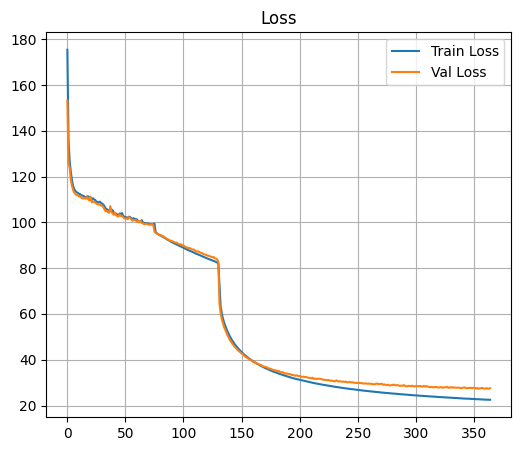

<Figure size 640x480 with 0 Axes>

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

# Loss
ax.plot(train_model.history['loss'], label='Train Loss')
ax.plot(train_model.history['val_loss'], label='Val Loss')
ax.set_title('Loss')
ax.legend()
ax.grid(True)

# Accuracy
# ax[1].plot(train_model.history['accuracy'], label='Train Accuracy')
# ax[1].plot(train_model.history['val_accuracy'], label='Val Accuracy')
# ax[1].set_title('Accuracy')
# ax[1].legend()
# ax[1].grid(True)

plt.show()
plt.savefig(f'/content/drive/MyDrive/Sesac/한상훈과아이들/Dev_STT_Model/tensorflow/{save_folder}/{train_model.history['val_loss'][-11]}.png')